# Summer '26
## Author: Zane Collins
## Last Updated: 06/17/2026


# Imports

In [1]:
from hapi import *

HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

from scipy.signal import correlate

%matplotlib widget

# Parsing

In [11]:
db_begin("HAPI_DB");

Using HAPI_DB



In [22]:
tableList()

dict_keys(['sampletab', 'CH4', 'H2O'])

In [64]:
wn_min = 600
wn_max = 6000


## CH4 & Water Fetching

In [57]:
# Isotopes to download:
ch4_isotopes = [1,2]
h2o_isotopes = [1,2,3]

In [ ]:
for isotope in ch4_isotopes:
    fetch(f"CH4_iso{isotope}", 6, isotope, wn_min, wn_max)
for isotope in h2o_isotopes:
    fetch(f"H2O_iso{isotope}", 1, isotope, wn_min, wn_max)


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: CH4_iso1
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1

# Helper Functions

In [72]:
def compute_transmission(molecule, isotope, dwn, T = 288, p = 1, column_density = 1e12, path_length = 1e5):

    #Check if the molecule and isotope are in the database
    table_name = f"{molecule}_iso{isotope}"
    # if table_name not in [t[0] for t in tableList()]:
    #     raise ValueError(f"{molecule} with isotope {isotope} not found in database. Table {table_name}")
    
    #Fetch the absorption coefficients for the specified molecule and isotope
    wn_grid, coef = absorptionCoefficient_Voigt(
            Components=[(6, isotope, 1)],
            SourceTables=table_name,
            WavenumberRange=(wn_min, wn_max),
            WavenumberStep=dwn,
            Environment={'T': T, 'p': p} 
        )
    
    # Calculate the transmission using the Beer-Lambert law
    tau = coef * column_density * path_length
    transmission = np.exp(-tau)

    wavelength_grid = 1e4 / wn_grid
    resolution = np.median(wn_grid) / dwn

    return wavelength_grid, transmission, resolution

def generate_res_isotope_dict(molecules,isotopes,dwns, T = 288, p = 1, column_density = 1e12, path_length = 1e5):
    res_isotope_dict = {} #Initialize an empty dictionary to store results for each isotope 
    for mol in molecules:
        res_isotope_dict[mol] = {}
        for dwn in dwns:
            res_isotope_dict[mol][dwn] = {}
            for isotope in isotopes:
                wavelength_grid, transmission, resolution = compute_transmission(mol, isotope, dwn, T, p, column_density, path_length)
                res_isotope_dict[mol][dwn][isotope] = (wavelength_grid, transmission, resolution)
        
    return res_isotope_dict

def create_combined_transmission(data_dict, molecule_abundances, dwn, T=None, p=None):
    """
    molecule_abundances: dict[molecule] = dict[isotope] = fractional abundance (or column density scaling)
    Example: {'CH4': {1: 0.8, 2: 0.2}, 'H2O': {1: 1.0}}
    """
    tau_total = None
    wl_grid = None
    
    for mol, iso_abund in molecule_abundances.items():
        for iso, frac in iso_abund.items():
            try:
                data = data_dict[mol][dwn][iso]
                current_wl = data[0]
                trans = data[1]
            except KeyError:
                print(f"Missing data for {mol} iso {iso} at dwn {dwn}")
                continue
                
            if wl_grid is None:
                wl_grid = current_wl
            
            tau = -np.log(np.clip(trans, 1e-10, 1.0))  # avoid log(0), tau = -ln(T) = -ln(exp(-tau)) = tau
            tau_total = tau * frac if tau_total is None else tau_total + tau * frac # Sum the optical depths weighted by their fractional abundances
    
    if tau_total is None:
        raise ValueError("No data found for any species")
    
    combined_trans = np.exp(-tau_total)
    return wl_grid, combined_trans

# Noise injection
def inject_poisson_noise(data, SNR):

    signal = np.average(data)  # Representative signal level for scaling noise
    print(f"Average signal level: {signal:.4e}")
    scale = signal / SNR if signal > 0 else 1.0 
    print(f"scale factor: {scale:.4e} for SNR={SNR}")

    poisson_noise = np.random.poisson(lam=data)
    poisson_noise = poisson_noise - data  # Center the noise around zero
    
    noisy_data = data + poisson_noise * scale / np.sqrt(signal)  # Scale noise by SNR and signal level
    noisy_data = np.clip(noisy_data, 0, None)  # Ensure non-negative values

    errorbars = np.sqrt(data) * scale / np.sqrt(signal)  # Poisson noise error bars

    return noisy_data, errorbars

def inject_gaussian_noise(data, SNR, seed = 8):

    signal = np.max(data) 
    sigma = signal / SNR

    nchan = len(data)
    rng = np.random.default_rng(seed)
    random_pertubations = sigma*rng.standard_normal(nchan)


    synthetic_atmosphere = data + random_pertubations 
    synthetic_atmosphere = np.clip(synthetic_atmosphere, 0, None) 
    
    errorbars = np.full_like(data, sigma) 
    return synthetic_atmosphere, errorbars




# Test

In [70]:
dwns = [0.1,1]
ch4_isos = [1,2]
h2o_isos = [1]

data_dict = generate_res_isotope_dict(['CH4','H2O'], ch4_isos, dwns, T=288, p=1, column_density=1e12, path_length=1e5)

{'air': 1.0}
49.848652 seconds elapsed for abscoef; nlines = 194110
{'air': 1.0}
18.495062 seconds elapsed for abscoef; nlines = 79200
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


38.564010 seconds elapsed for abscoef; nlines = 194110
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


18.541558 seconds elapsed for abscoef; nlines = 79200
{'air': 1.0}
1.275004 seconds elapsed for abscoef; nlines = 53108
{'air': 1.0}
0.335999 seconds elapsed for abscoef; nlines = 14038
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


1.304419 seconds elapsed for abscoef; nlines = 53108
{'air': 1.0}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/hapi/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


0.336191 seconds elapsed for abscoef; nlines = 14038


In [73]:
test_molecule_abundances = {'CH4': {1: 0.8, 2: 0.2}, 'H2O': {1: 1.0}}
wl_grid, combined_trans = create_combined_transmission(data_dict, test_molecule_abundances, dwn=0.1, T=288, p=1)

In [82]:
print(data_dict['CH4'][0.1][1][2])

33000.0


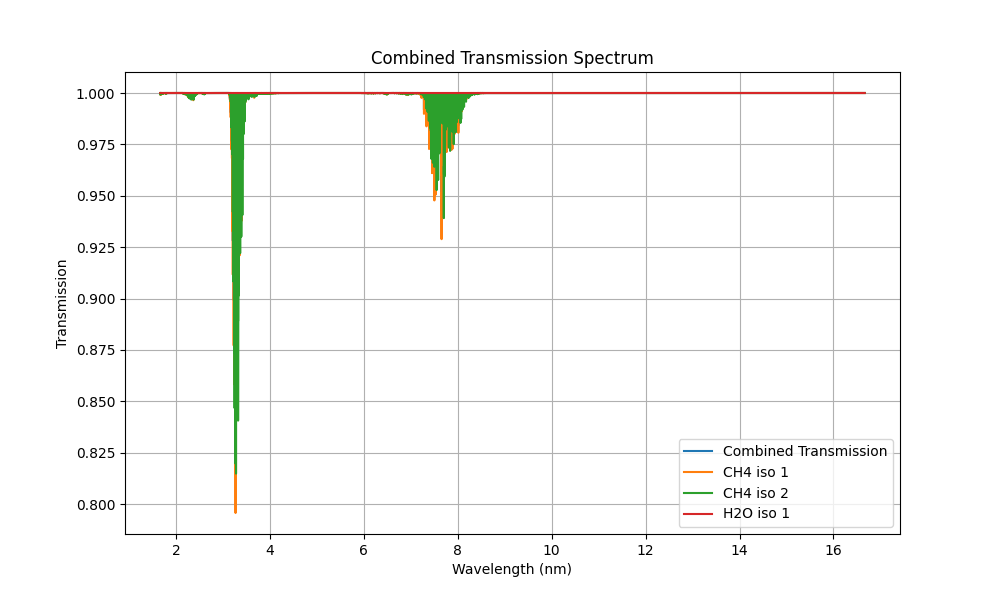

In [83]:
plt.figure(figsize=(10, 6))
plt.plot(wl_grid, combined_trans, label='Combined Transmission')
plt.plot(data_dict['CH4'][0.1][1][0], data_dict['CH4'][0.1][1][1], label='CH4 iso 1')
plt.plot(data_dict['CH4'][0.1][2][0], data_dict['CH4'][0.1][2][1], label='CH4 iso 2')
plt.plot(data_dict['H2O'][0.1][1][0], data_dict['H2O'][0.1][1][1], label='H2O iso 1')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Combined Transmission Spectrum')
plt.legend()
plt.grid()